In [1]:
# imports
import os
import sys
import time
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import clear_output
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_timestamp

In [2]:
# config proxy
os.environ['http_proxy'] = 'http://proxy.iutn.univ-poitiers.fr:3128'
os.environ['https_proxy'] = 'http://proxy.iutn.univ-poitiers.fr:3128'

In [3]:
# Démarrage de la session Spark
username = os.environ.get('USER', 'unknown')
spark = SparkSession.builder \
    .appName(f"Dashboard-{username}") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()


spark.sparkContext.setLogLevel("WARN")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/08 22:41:35 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/02/08 22:41:37 WARN Client: Neither spark.yarn.jars nor spark.yarn.archive is set, falling back to uploading libraries under SPARK_HOME.


In [4]:
input_path = f"/user/{username}/streaming_results"
print(f"Dashboard connecté à : {input_path}")

Dashboard connecté à : /user/ldixne01/streaming_results


#### Fonction de chargement et préparation

In [5]:
def load_data():
    try:
        # Lecture des JSON accumulés sur HDFS
        df_spark = spark.read.json(input_path)
        
        # On vérifie que les colonnes existent (au cas où le dossier est vide au début)
        if "predicted_sentiment" not in df_spark.columns:
            return None

        # Conversion en Pandas pour la visualisation
        # Note : Sur un vrai Big Data, on agrégerait avec Spark avant le toPandas(). 
        # Ici avec 600k lignes, ça passe en mémoire driver.
        pdf = df_spark.select("user", "event_time", "predicted_sentiment", "text").toPandas()
        
        # Conversion du string event_time en datetime pour les graphiques temporels
        pdf['event_time'] = pd.to_datetime(pdf['event_time'])
        
        return pdf
    except Exception as e:
        print(f"En attente de données... ({e})")
        return None

#### Création des graphiques KPIs, line charts et bar charts

In [6]:
import re

# question 7.2 : Système d'alerte intelligent (Z-Score)
def get_smart_alert_message(pdf):
    # On groupe par minute pour voir le volume de tweets négatifs
    ts_data = pdf.set_index('event_time').resample('1min')['predicted_sentiment'].apply(lambda x: (x == 0).sum())
    
    if len(ts_data) < 5:
        return "Calibrage du système d'alerte (historique insuffisant)..."
    
    current_val = ts_data.iloc[-1]
    # On compare la dernière minute à l'historique d'avant
    history = ts_data.iloc[:-1]
    mean = history.mean()
    std = history.std() if history.std() > 0 else 1
    
    # Calcul du Z-Score (Combien d'écarts-types au-dessus de la moyenne ?)
    z_score = (current_val - mean) / std
    
    if z_score > 3.0:
        return f"🚨 ALERTE CRITIQUE : Explosion de négativité ! (Z-Score: {z_score:.1f})"
    elif z_score > 2.0:
        return f"⚠️ ATTENTION : Activité négative anormale (Z-Score: {z_score:.1f})"
    else:
        return f"✅ Situation Normale (Z-Score: {z_score:.1f})"

# question 7.3 : Indicateur (vitesse de propagaation des hashtags)
def plot_hashtag_velocity(pdf):
    # On se concentre sur l'activité immédiate (les 1000 derniers tweets)
    recent = pdf.tail(1000)
    
    if recent.empty: return None

    # Extraction des hashtags via Regex
    # On cherche les mots commençant par # suivi de caractères alphanumériques
    all_hashtags = []
    for text in recent['text'].astype(str):
        tags = re.findall(r"#(\w+)", text) # On capture le mot sans le #
        all_hashtags.extend(tags)
        
    if not all_hashtags:
        return None

    # On compte les occurrences (Top 10)
    counts = Counter(all_hashtags).most_common(10)
    df_hashtags = pd.DataFrame(counts, columns=['hashtag', 'velocity'])
    
    # On ajoute un préfixe '#' pour l'affichage
    df_hashtags['hashtag'] = '#' + df_hashtags['hashtag']
    
    # Graphique : Bar chart horizontal trié
    fig = px.bar(
        df_hashtags, 
        x='velocity', 
        y='hashtag', 
        orientation='h',
        title="Vitesse de propagation (Trending Topics)",
        labels={'velocity': 'Occurrences (sur 1000 tweets)', 'hashtag': 'Hashtag'},
        color='velocity',
        color_continuous_scale='Hot' # Couleurs chaudes pour montrer le "feu" de la viralité
    )
    
    # On inverse l'axe Y pour avoir le top 1 en haut
    fig.update_layout(yaxis=dict(autorange="reversed"), height=300, margin=dict(t=40, b=10))
    
    return fig

In [7]:
from collections import Counter
import plotly.graph_objects as go
import plotly.express as px

# Liste simple de mots vides (anglais) à ignorer pour l'analyse de texte
STOPWORDS = {'the', 'to', 'and', 'a', 'of', 'in', 'is', 'for', 'on', 'that', 'it', 'with', 'at', 'i', 'my', 'this', 'be', 'are', 'not', 'have', 'so', 'was', 'but', 'me', 'rt'}

def plot_dashboard(pdf):
    # Mapping pour l'affichage propre
    sentiment_map = {0.0: 'Négatif', 1.0: 'Positif'}
    color_map = {'Négatif': '#EF553B', 'Positif': '#00CC96'} # Rouge / Vert
    
    # On ajoute une colonne lisible pour les graphiques
    pdf['sentiment_label'] = pdf['predicted_sentiment'].map(sentiment_map)

    # =================================================================
    # 1. KPI : Donut Chart (Répartition & Volume Total)
    # =================================================================
    # C'est plus clair que la jauge : on voit le volume et la part du gâteau
    sentiment_counts = pdf['sentiment_label'].value_counts().reset_index()
    sentiment_counts.columns = ['sentiment', 'count']
    
    fig_donut = px.pie(
        sentiment_counts, 
        values='count', 
        names='sentiment',
        title=f"Répartition Totale ({len(pdf)} tweets)",
        color='sentiment',
        color_discrete_map=color_map,
        hole=0.5 # Pour faire le trou au milieu (Donut)
    )
    # Afficher le total au centre
    fig_donut.update_layout(annotations=[dict(text=str(len(pdf)), x=0.5, y=0.5, font_size=20, showarrow=False)])

    # =================================================================
    # 2. Évolution du Volume (Stacked Bar Chart)
    # =================================================================
    # Au lieu d'une moyenne, on compte combien de + et de - par tranche de temps.
    # On groupe par tranche de 1 minute (ou 30s) pour lisser le graphique
    df_time = pdf.set_index('event_time').groupby(
        [pd.Grouper(freq='1min'), 'sentiment_label']
    ).size().reset_index(name='count')
    
    fig_hist = px.bar(
        df_time, 
        x='event_time', 
        y='count', 
        color='sentiment_label',
        title="Volume de tweets par minute (Positif vs Négatif)",
        labels={'count': 'Nombre de tweets', 'event_time': 'Temps'},
        color_discrete_map=color_map,
        barmode='stack' # Empilé : on voit le volume total ET la proportion
    )

    # =================================================================
    # 3. Top Mots (inchangé, c'est utile)
    # =================================================================
    sample_recent = pdf.tail(2000) # On analyse un peu plus de tweets récents
    
    def get_top_words(df_subset):
        text = " ".join(df_subset['text'].astype(str)).lower()
        words = [w for w in text.split() if w.isalpha() and w not in STOPWORDS and len(w) > 3]
        return Counter(words).most_common(10)

    top_pos = get_top_words(sample_recent[sample_recent['predicted_sentiment'] == 1.0])
    top_neg = get_top_words(sample_recent[sample_recent['predicted_sentiment'] == 0.0])
    
    df_words = pd.concat([
        pd.DataFrame(top_pos, columns=['word', 'count']).assign(sentiment='Positif'),
        pd.DataFrame(top_neg, columns=['word', 'count']).assign(sentiment='Négatif')
    ])
    
    fig_words = px.bar(
        df_words, x='count', y='word', color='sentiment',
        orientation='h', facet_col='sentiment',
        title="Quels sont les sujets du moment ?",
        color_discrete_map=color_map
    )

    # =================================================================
    # 4. Tableau des Derniers Tweets (inchangé)
    # =================================================================
    latest_tweets = pdf.sort_values('event_time', ascending=False).head(8)
    
    fig_table = go.Figure(data=[go.Table(
        header=dict(values=['Heure', 'User', 'Tweet', 'Sentiment'],
                    fill_color='paleturquoise', align='left'),
        cells=dict(values=[
            latest_tweets['event_time'].dt.strftime('%H:%M:%S'),
            latest_tweets['user'],
            latest_tweets['text'].str.slice(0, 60) + "...",
            latest_tweets['sentiment_label']
        ], fill_color='lavender', align='left'))
    ])
    fig_table.update_layout(title="Flux temps réel", height=350, margin=dict(t=30, b=10))

    # =================================================================
    # Affichage
    # =================================================================
    # On affiche d'abord les KPIs globaux, puis l'évolution, puis les détails
    fig_donut.show()
    fig_hist.show()
    fig_words.show()
    fig_table.show()

#### Boucle de rafraichissement automatique

=== DASHBOARD MONITORING - 22:43:02 ===

✅ Situation Normale (Z-Score: -28.0)



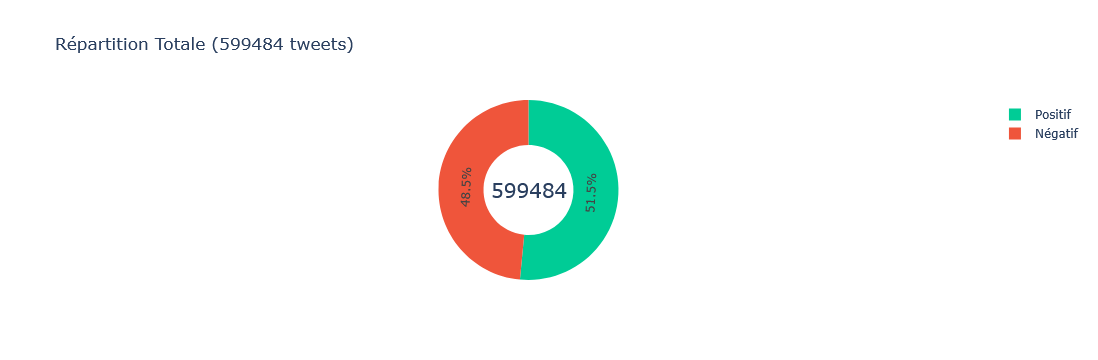

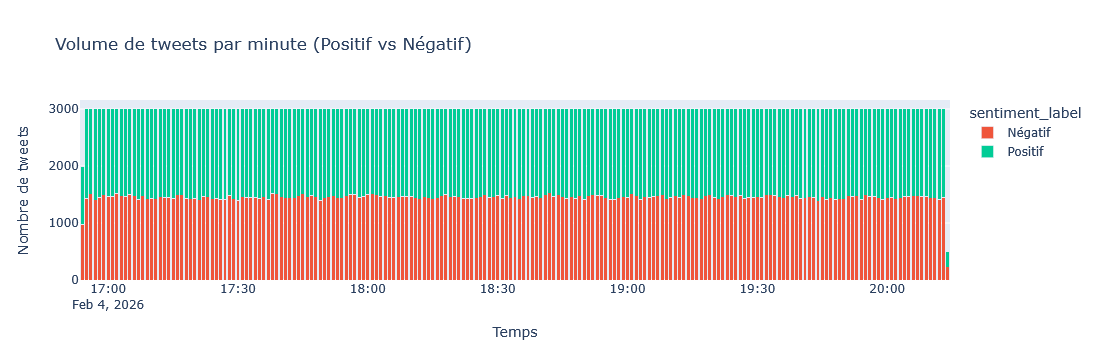

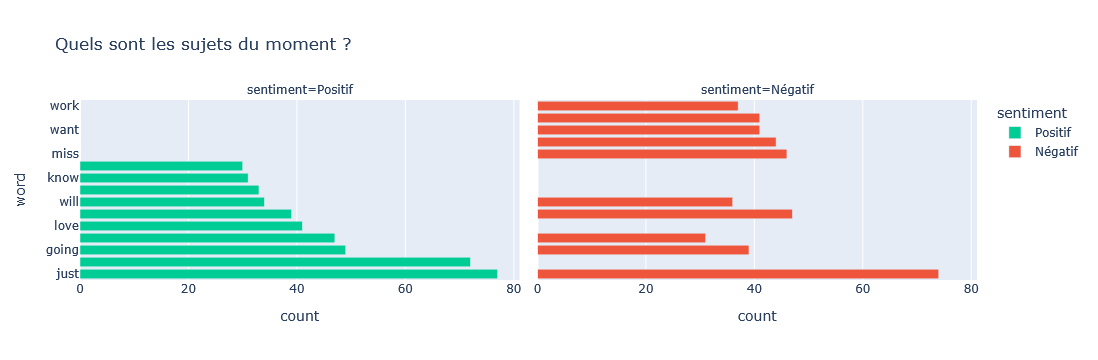

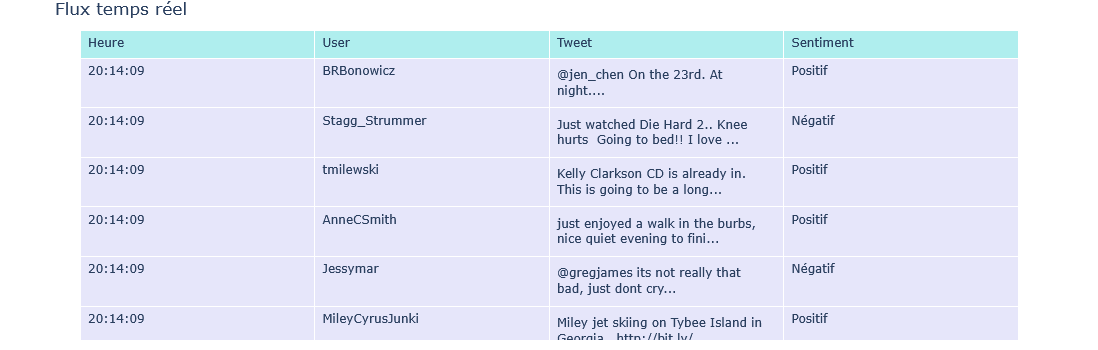

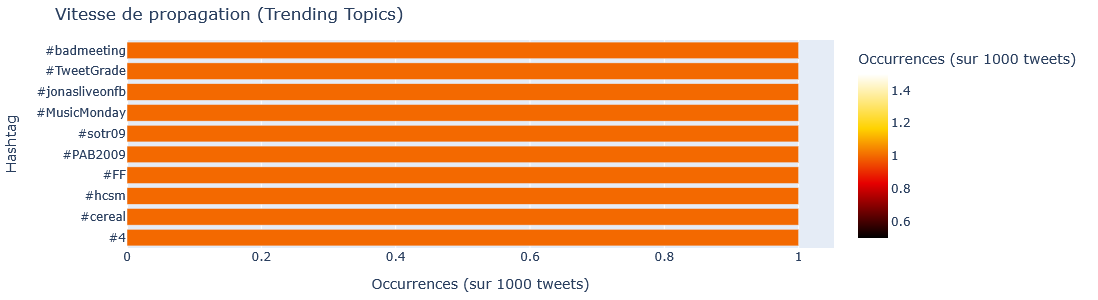

Arrêt.


In [8]:
print("Démarrage du Dashboard Final (avec Questions Ouvertes 7.2 et 7.3)...")

try:
    while True:
        pdf = load_data()
        
        if pdf is not None and not pdf.empty:
            clear_output(wait=True)
            print(f"=== DASHBOARD MONITORING - {pd.Timestamp.now().strftime('%H:%M:%S')} ===")
            
            # 1. Alerte Intelligente (Q 7.2)
            alert = get_smart_alert_message(pdf)
            print(f"\n{alert}\n")
            
            # 2. Graphiques Standards
            plot_dashboard(pdf)
            
            # 3. Indicateur vitesse hashtags (Q 7.3)
            fig_viral = plot_hashtag_velocity(pdf)
            if fig_viral: 
                fig_viral.show()
            else:
                print("Pas de hashtags détectés pour le moment.")
            
        else:
            print("En attente de données...")
            
        time.sleep(5)

except KeyboardInterrupt:
    print("Arrêt.")

In [11]:
spark.stop()
print("SparkSession arretee.")

SparkSession arretee.
